In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Fijamos la semilla aleatoria
np.random.seed(42) #¿Por qué 42? https://en.wikipedia.org/wiki/Phrases_from_The_Hitchhiker%27s_Guide_to_the_Galaxy

# Cambiamos aspecto de los gráficos
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

**Medida de distancia entre patrones: Distancia Euclídea**

Dados dos patrones $x=(x_1, x_2, ..., x_n)$ e $y=(y_1, y_2, ..., y_n)$, se calcula como:

$d(x, y)= \sqrt{\sum_{i=1}^n \left(x_i-y_i\right)^2}$

In [ ]:

# Distancia a usar como métrica de similitud entre patrones
def euclidean(x, y):
  return np.sqrt( np.sum( (x-y)**2, axis=-1) )


**Predicción del cluster de un conjunto de patrones:**

Dado un patrón $x$ y un conjunto de centroides $\{c\}$. El cluster $k$ al que se asocia el elemento $x$ se calcula como:

$k= argmin_i\{ d(x, c_i) \}$

In [ ]:

# Cálculo del centroide más próximo a los patrones X
def predict(X, centroides):

  # Expandimos X para poder hacer cálculos de forma matricial
  # más eficientemente con la característica de NumPy para broadcasting
  X= np.repeat(X, centroides.shape[0], axis=0).reshape(-1, centroides.shape[0], centroides.shape[1])

  # Calculamos las distancias de cada elemento de X a los centroides
  distancias= euclidean(X, centroides)

  # Calculamos el cluster más próximo a cada elemento de X
  clusters= np.argmin(distancias, axis= -1)
  return clusters.reshape(-1)


**Medida Within-Cluster Sum of Squares (WCSS)**

Sirve para calcular cómo de bien se agrupan los elementos de un cluster con respecto a su centroide.

Si tenemos $K$ centroides $\{c_i\}_{i=1}^K$, y el $i$-ésimo cluster tiene centroide $c_i$ con $n_i$ elementos del cluster $\{x_j^{(i)}\}_{j=1}^{n_i}$, entonces el WCSS se calcula como:

$WCSS= \sum_{i=1}^K\sum_{j=1}^{n_i} (d(x_j^{(i)}, c_i))^2$

In [ ]:

# Cálculo de la métrica Within-Cluster Sum of Squares (WCSS).
def WCSS(X, clusters, centroides):

  wcss= 0
  for i in range(len(centroides)):
    centroid_i= centroides[i, :].squeeze()
    elementos_cluster= X[clusters==i, :].squeeze()

    distancias_sqr= euclidean(elementos_cluster, centroid_i)**2
    wcss+= np.sum(distancias_sqr)
  return wcss


**La métrica Silhouette Score:**


El coeficiente de silueta (*Silhouette Score*) es una métrica que mide lo bien que cada patrón encaja en su cluster asignado. Combina información sobre la cohesión y la separación de los clusters.

- La **cohesión** se refiere a cómo de cercanos se encuentran los puntos de un cluster con respecto a los demás miembros del cluster.

- La **separación** se refiere a cómo de lejos se encuentra un punto de los puntos de otros clusters.

El coeficiente de silueta proporciona un valor en el rango $[-1, 1]$, donde un valor próximo a 1 indica que el punto está bien agrupado, un valor próximo a 0 indica que hay solapamiento entre clusters, y un valor próximo a -1 sugiere que el punto está asignado a un cluster de forma incorrecta.

Para un patrón dado $i$, su coeficiente silueta se calcula como:

$S_{score}(i) = {{separation — cohesion}\over{max(separation, cohesion)}}$

El valor del coeficiente global de todo el conjunto de datos se calcula como la media aritmética de todos los coeficientes individuales. Si el dataset contiene $N$ elementos $\{x_i\}_{i=1}^L$, entonces:

$S_{score}= {1\over N}\sum_{i=1}^N S_{score}(i)$

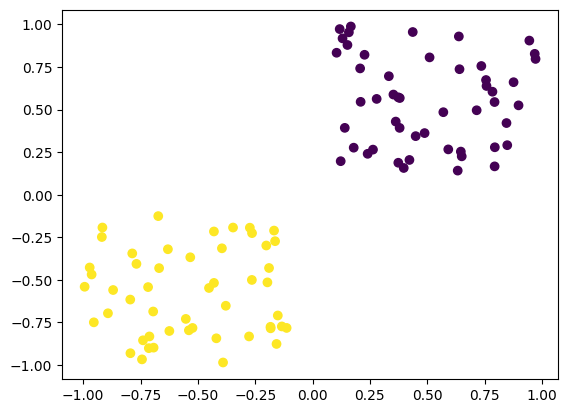

La S-score es 0.683633530164178


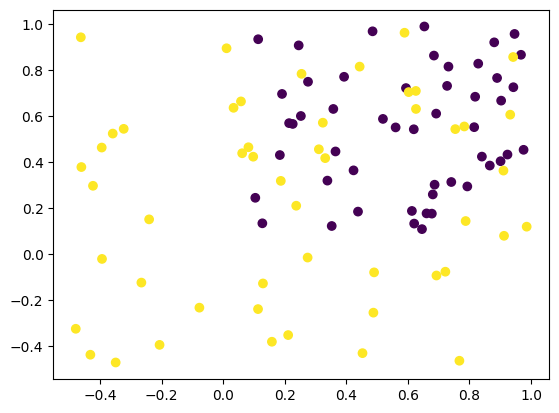

La S-score es 0.14166266894412285


In [ ]:
from sklearn.metrics import silhouette_score

# Ejemplo con dos clusters: Uno formado por pares de números negativos
#  y otro formado por pares de positivos

positivos= np.random.uniform(low=0.1, high= 1, size=(50, 2))  # 50 positivos
negativos= np.random.uniform(low=-1, high= -0.1, size=(50, 2)) # 50 negativos
todos= np.vstack( (positivos, negativos) )

# Clusters de cada patrón generado
clusters= np.concatenate( (np.zeros(50, dtype=int)+1, 1+np.ones(50, dtype=int)) )

plt.scatter(todos[:, 0], todos[:, 1], c=clusters)
plt.show()

print('La S-score es {}'.format( silhouette_score(todos, clusters )))




#####
# Otro ejemplo con clusters superpuestos

# Ejemplo con dos clusters: Uno formado por pares de números en [0, 1]
#  y otro formado por pares de números en [-0.5, 1]
positivos= np.random.uniform(low=0.1, high= 1, size=(50, 2))  # 50 positivos
negativos= np.random.uniform(low=-0.5, high= 1, size=(50, 2)) # 50 negativos
todos= np.vstack( (positivos, negativos) )

# Clusters de cada patrón generado
clusters= np.concatenate( (np.zeros(50, dtype=int)+1, 1+np.ones(50, dtype=int)) )

plt.scatter(todos[:, 0], todos[:, 1], c=clusters)
plt.show()

print('La S-score es {}'.format( silhouette_score(todos, clusters )))


**El algoritmo K-Means.**

Es iterativo. Tiene fundamentalmente dos pasos en cada iteración:

1. **Agrupamiento**: Cálculo del cluster para cada elemento.
2. **Optimización de centroides**: Cálculo de nuevos centroides según el agrupamiento realizado.

In [ ]:
# Algoritmo KMeans
#   X: tabla de X.shape[0] patrones de dimensión X.shape[1] a agrupar
#   n_clusters: Número de clusters a generar
#   max_iter: Máximo de iteraciones permitidas
def KMeans(X, n_clusters, max_iter, debug=False):

  # Selección de centroides aleatorios
  seleccion= np.random.choice(len(X), size=n_clusters, replace= False)
  centroides= X[seleccion].copy()

  converged= False # Parada temprana si se converge

  # Algoritmo
  for it in range(max_iter):

    # Buscamos clusters para cada elemento de X
    clusters= predict(X, centroides)

    # Recalculamos centroides
    centroides_old= centroides.copy()
    for i in range(len(centroides)):
      elementos_cluster= X[clusters==i, :].reshape(-1, X.shape[1])
      centroides[i, :]= np.mean(elementos_cluster, axis=0)

    # Comprobamos convergencia
    converged= np.all(centroides == centroides_old)
    if converged:
      if debug:
        print('CONVERGE')
      return centroides

    # Mostramos resultados
    if debug:
      wcss= WCSS(X, clusters, centroides)
      print('It. {}. WCSS: {}'.format(it+1, wcss))

  # Fin
  print('NO CONVERGE. FIN ITERACIONES.')
  return centroides



# Ejemplo:

Generación de datos (4 clusters)

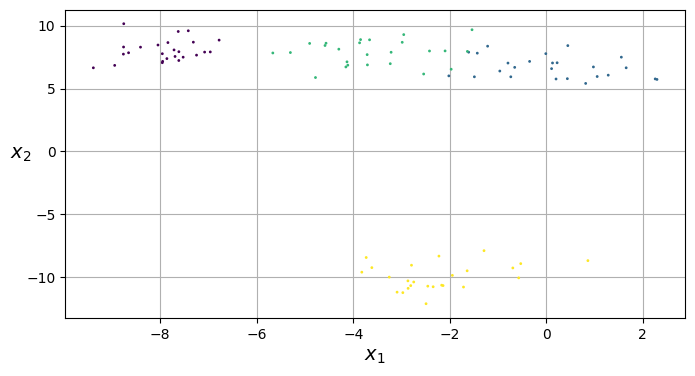

In [ ]:
from sklearn.datasets import make_blobs

clusters_real= 4 # Número de clusters a generar

# Generación de clusters
X, y= make_blobs(n_samples=100, n_features=2, centers= clusters_real)

# Función auxiliar para mostrar los clusters
def plot_clusters(X, y=None):
  plt.figure(figsize=(8, 4))
  plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
  plt.xlabel("$x_1$")
  plt.ylabel("$x_2$", rotation=0)
  plt.gca().set_axisbelow(True)
  plt.grid()
  plt.show()

# Mostrar el dataset
plot_clusters(X, y)



Experimentación con varios números de clusters para hallar el mejor resultado según la regla del codo.

In [ ]:

# Diccionario para guardar los centroides de todas las pruebas
centroides_totales= {}

wcss= [] # Listado de WCSS para cada solución
Sscore= [] # Listado de Silhouette Scores para cada solución


# Generamos soluciones desde 2 a max_clusters clusters
max_clusters= 10
for num_clusters in range(2, max_clusters+1):

  # Calculamos solución para num_clusters clusters
  centroides= KMeans(X, n_clusters=num_clusters, max_iter= 10, debug= False)

  # Calculamos el WCSS de la solución
  clusters= predict(X, centroides)
  wcss.append( WCSS(X, clusters, centroides) )

  # Cálculo de la S-Score
  Sscore.append( silhouette_score(X, clusters) )

  # Guardamos solución
  centroides_totales[num_clusters]= centroides

  # Mostramos solución gráfica
  #plot_clusters(X, clusters)

Mostramos la gráfica del números de clusters (eje X) y el WCSS (eje Y) para seleccionar el mejor.

Si seguimos la regla del codo, el mejor número de clusters que se plantea es **4 clusters**.


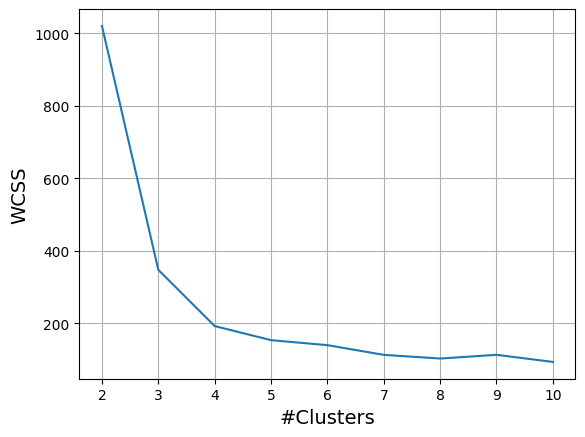

In [ ]:
plt.plot(np.arange(2, max_clusters+1), wcss)
plt.xlabel('#Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

Mostramos la gráfica de evolución de la S-Score

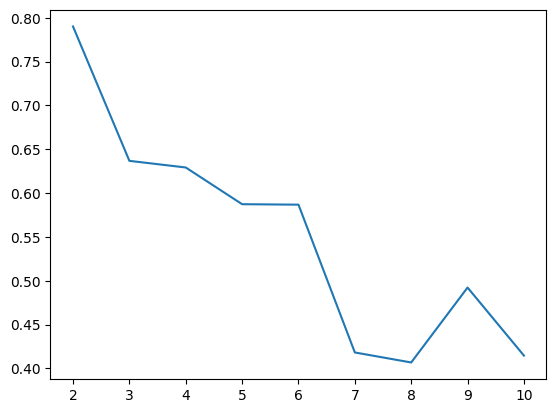

In [ ]:
plt.plot( np.arange(2, max_clusters+1), Sscore )